In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight

# Chemins
train_dir = "/kaggle/input/datasets/msambare/fer2013/train"
test_dir = "/kaggle/input/datasets/msambare/fer2013/test"

img_size = 48 # FER-2013 est en 48x48
batch_size = 64

2026-04-28 20:40:48.095786: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777408848.284087      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777408848.339117      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777408848.789200      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777408848.789235      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777408848.789238      57 computation_placer.cc:177] computation placer alr

In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    color_mode='rgb', 
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical'
)

# Calcul des poids de classes pour équilibrer l'importance
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights_dict = dict(enumerate(class_weights))
print("Poids des classes calculés :", class_weights_dict)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Poids des classes calculés : {0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(64, (3,3), padding='same', activation='relu', input_shape=(48, 48, 3)),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.2), # Réduit de 0.25 à 0.2

    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.2),

    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.2),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4), # Réduit de 0.5 à 0.4
    Dense(7, activation='softmax')
])

# AUGMENTATION du Learning Rate : 0.001 au lieu de 0.00001
model.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777408892.485493      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [4]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

checkpoint = ModelCheckpoint(
    'emotion_model_final.keras', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max', 
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    verbose=1, 
    min_lr=0.00001
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=8, # On augmente la patience
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=50,
    validation_data=test_generator,
    validation_steps=test_generator.samples // batch_size,
    class_weight=class_weights_dict,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1777408920.272431     143 service.cc:152] XLA service 0x78cc84002350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777408920.272494     143 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777408921.200765     143 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/448 ━━━━━━━━━━━━━━━━━━━━ 1:39:16 13s/step - accuracy: 0.1875 - loss: 3.8886

I0000 00:00:1777408928.930433     143 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.1824 - loss: 2.3451
Epoch 1: val_accuracy improved from -inf to 0.25502, saving model to emotion_model_final.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 168s 347ms/step - accuracy: 0.1825 - loss: 2.3447 - val_accuracy: 0.2550 - val_loss: 1.9104 - learning_rate: 0.0010
Epoch 2/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.2812 - loss: 2.2783

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.25502 to 0.25977, saving model to emotion_model_final.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.2812 - loss: 2.2783 - val_accuracy: 0.2598 - val_loss: 1.8989 - learning_rate: 0.0010
Epoch 3/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.2708 - loss: 1.8745
Epoch 3: val_accuracy improved from 0.25977 to 0.35379, saving model to emotion_model_final.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 55s 122ms/step - accuracy: 0.2708 - loss: 1.8744 - val_accuracy: 0.3538 - val_loss: 1.6537 - learning_rate: 0.0010
Epoch 4/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.3750 - loss: 1.6890
Epoch 4: val_accuracy improved from 0.35379 to 0.35924, saving model to emotion_model_final.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3750 - loss: 1.6890 - val_accuracy: 0.3592 - val_loss: 1.6445 - learning_rate: 0.0010
Epoch 5/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.3561 - loss: 1.6603
Epoch 5: val_a

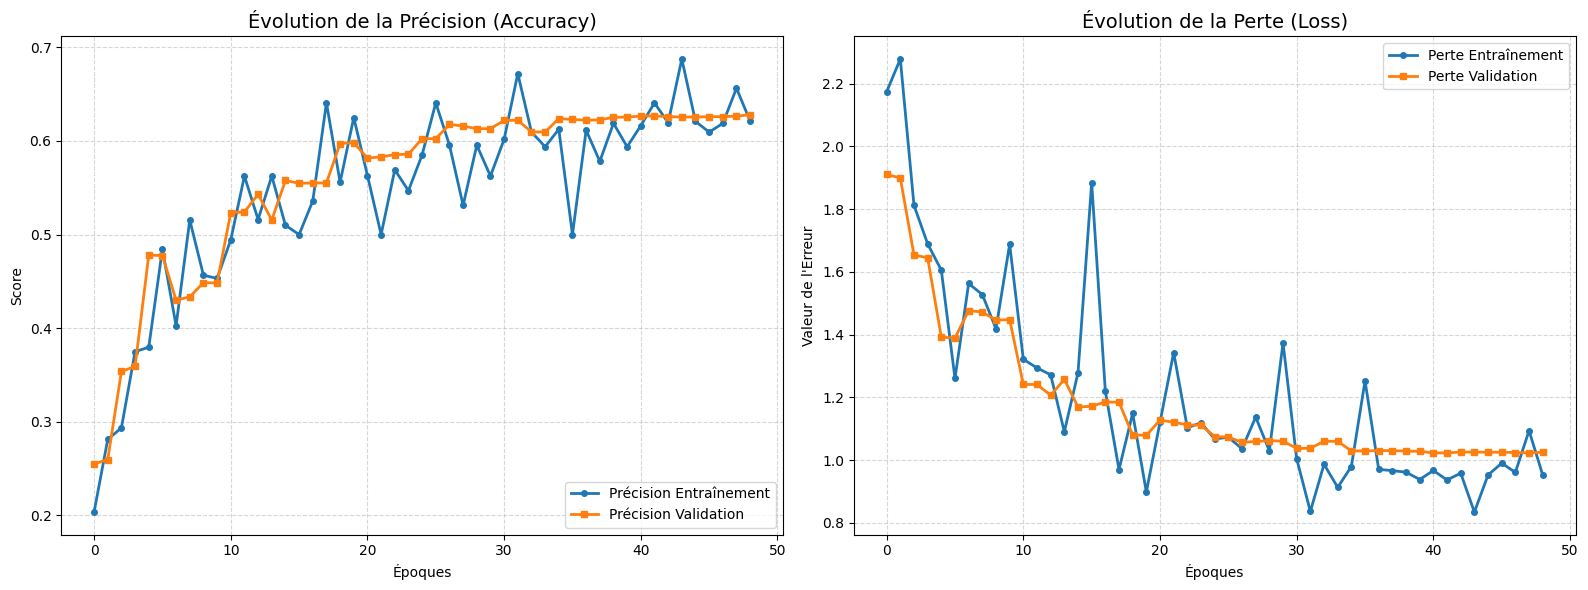

In [5]:
import matplotlib.pyplot as plt

# Récupération des données
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(16, 6))

# --- GRAPHIQUE PRÉCISION ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Précision Entraînement', color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.plot(epochs_range, val_acc, label='Précision Validation', color='#ff7f0e', linewidth=2, marker='s', markersize=4)
plt.title('Évolution de la Précision (Accuracy)', fontsize=14)
plt.xlabel('Époques')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# --- GRAPHIQUE PERTE ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Perte Entraînement', color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.plot(epochs_range, val_loss, label='Perte Validation', color='#ff7f0e', linewidth=2, marker='s', markersize=4)
plt.title('Évolution de la Perte (Loss)', fontsize=14)
plt.xlabel('Époques')
plt.ylabel('Valeur de l\'Erreur')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()